https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

In [9]:
df = pd.read_csv('../data/Dry_Bean_Dataset.csv')

In [10]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

In [12]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [7]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

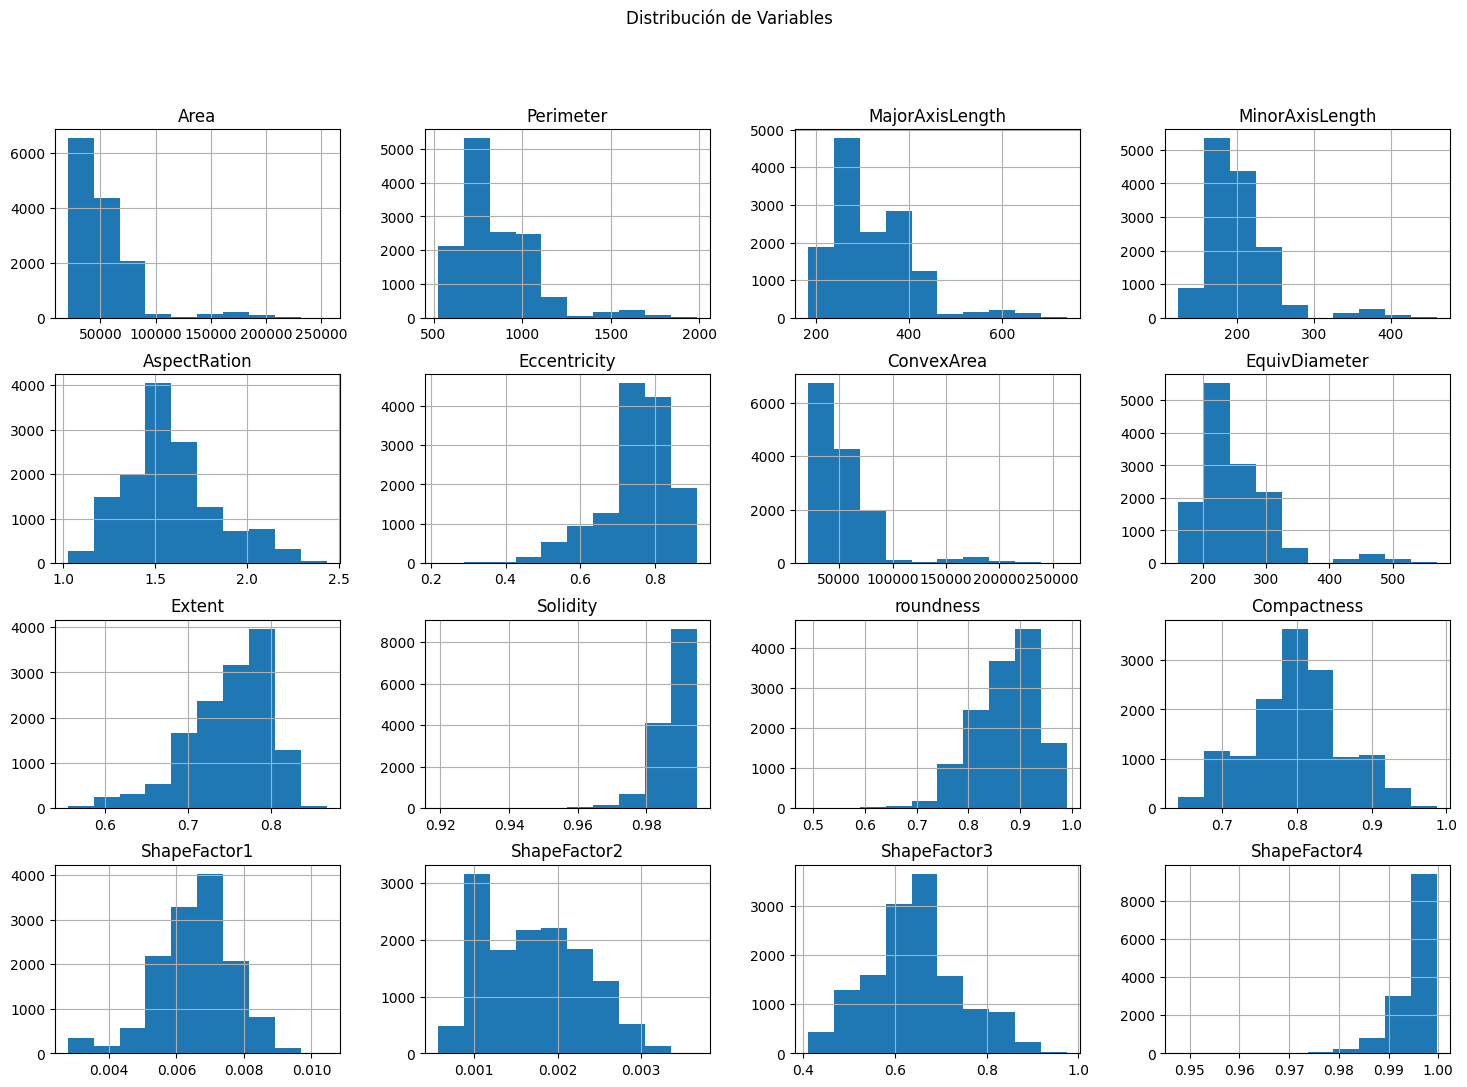

In [8]:
df.hist(figsize=(18,12))

plt.suptitle('Distribución de Variables')

plt.show()

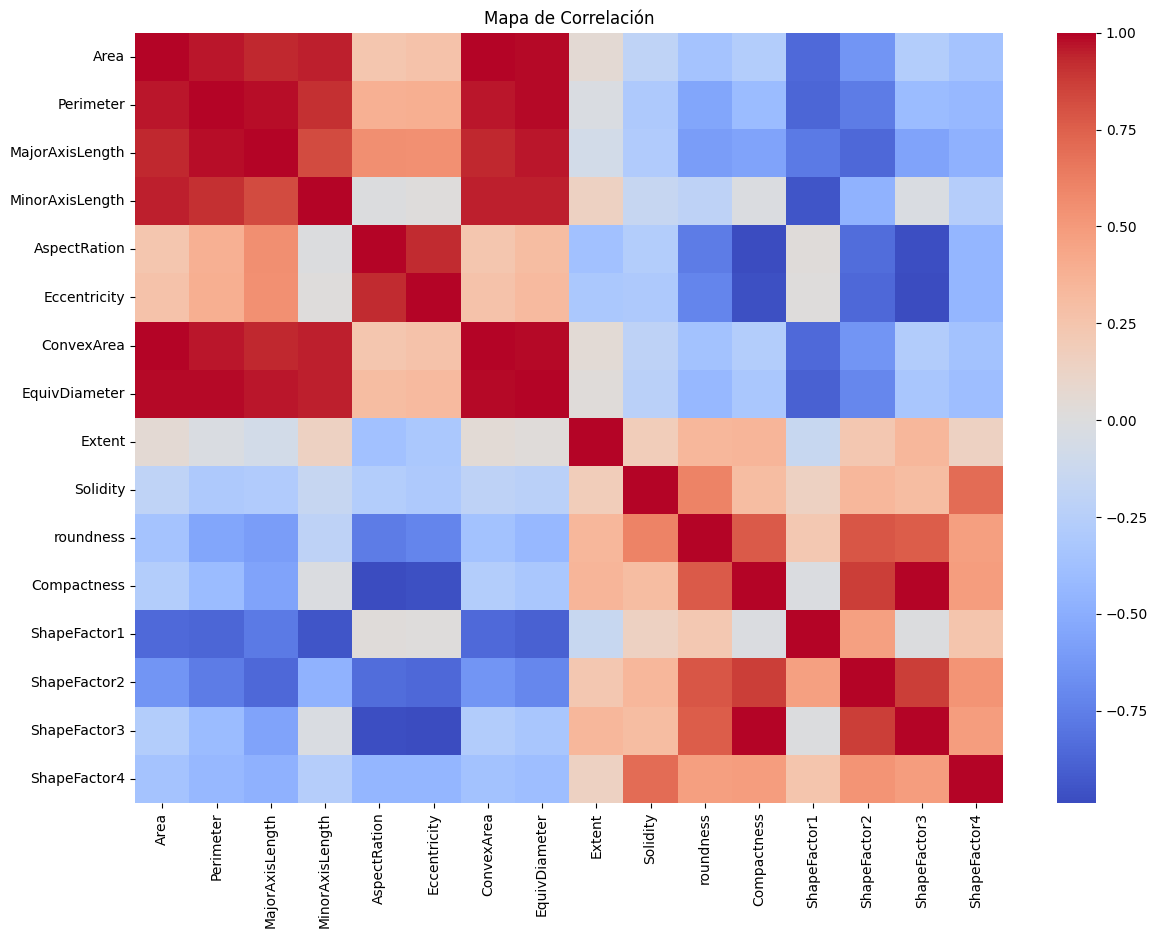

In [9]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title('Mapa de Correlación')

plt.show()

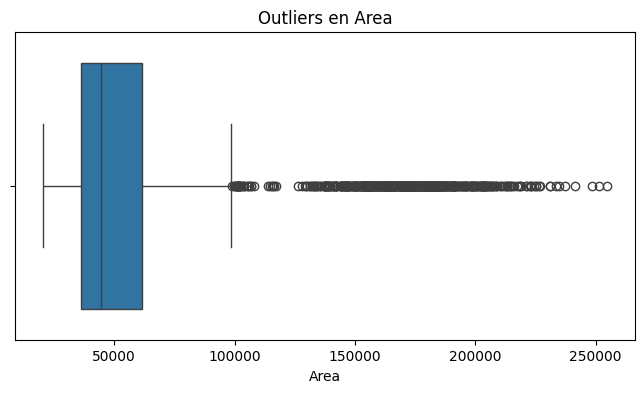

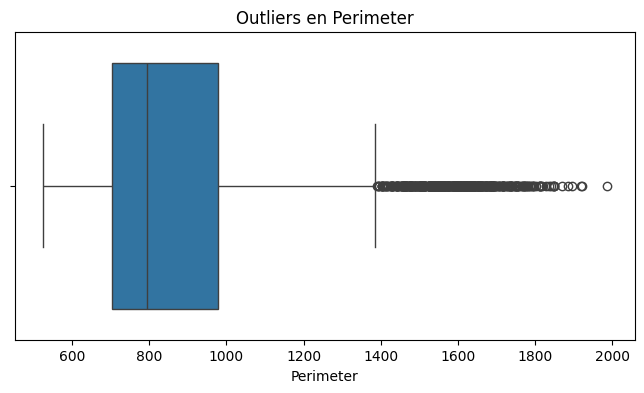

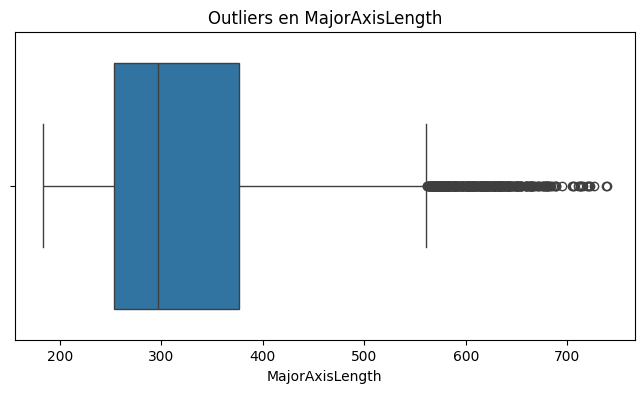

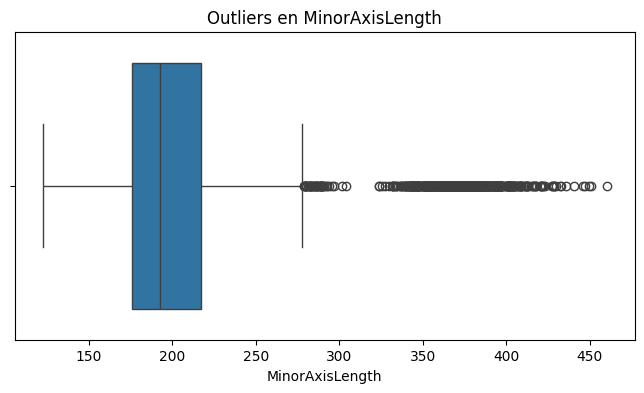

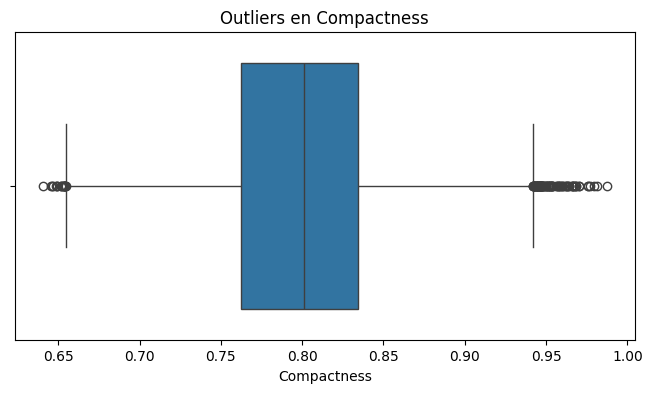

In [10]:
features_boxplot = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'Compactness'
]

for col in features_boxplot:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Outliers en {col}')
    
    plt.show()

In [ ]:
features = [
    'Area',
    'Perimeter',
    'MajorAxisLength',
    'MinorAxisLength',
    'Compactness'
]

In [12]:
X = df[features]

In [13]:
X.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Compactness
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.913358
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.953861
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.908774
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.928329
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.970516


In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
silhouette_scores = []

K = range(2,11)

best_score = -1
best_k = 2

for k in K:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    labels = model.labels_
    
    score = silhouette_score(X_scaled, labels)
    
    silhouette_scores.append(score)
    
    print(f'Clusters: {k} | Score: {score}')
    
    if score > best_score:
        
        best_score = score
        best_k = k

print('\n======================')
print(f'Mejor número de clusters: {best_k}')
print(f'Mejor Silhouette Score: {best_score}')

Clusters: 2 | Score: 0.42048093134775333
Clusters: 3 | Score: 0.42893123069909006
Clusters: 4 | Score: 0.3782835955845937
Clusters: 5 | Score: 0.40273640400526345
Clusters: 6 | Score: 0.39486148079634265
Clusters: 7 | Score: 0.34836485152644625
Clusters: 8 | Score: 0.35559940245875105
Clusters: 9 | Score: 0.34552816863226055
Clusters: 10 | Score: 0.34784748698804663

Mejor número de clusters: 3
Mejor Silhouette Score: 0.42893123069909006


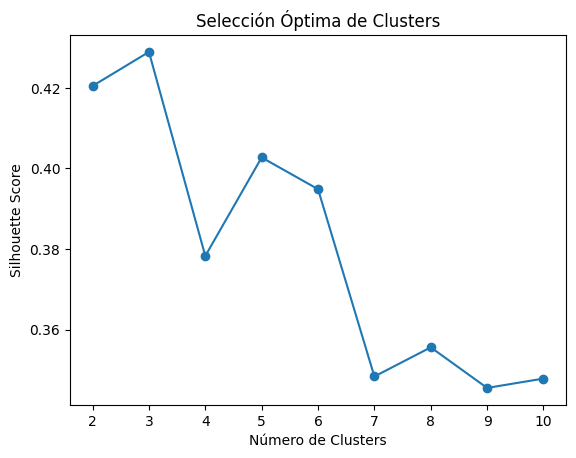

In [16]:
plt.plot(K, silhouette_scores, marker='o')

plt.xlabel('Número de Clusters')
plt.ylabel('Silhouette Score')

plt.title('Selección Óptima de Clusters')

plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [18]:
df['Cluster'] = kmeans.labels_

In [19]:
final_score = silhouette_score(
    X_scaled,
    kmeans.labels_
)

print(f'Silhouette Score Final: {final_score}')

Silhouette Score Final: 0.42893123069909006


In [20]:
df['Cluster'].value_counts()

Cluster
2    7796
0    5291
1     524
Name: count, dtype: int64

In [21]:
cluster_analysis = df.groupby('Cluster')[features].mean()

cluster_analysis

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Compactness
Cluster,,,,,,,,,,
0,63723.030240,984.506219,379.873203,213.497780,1.800766,0.822595,64702.720847,283.247727,0.733413,0.746282
1,173264.839695,1584.640353,592.700642,374.122583,1.585303,0.770403,175591.919847,468.617069,0.776500,0.792691
2,37723.303232,718.559415,261.283569,183.100270,1.435474,0.700922,38158.890585,218.091076,0.759010,0.836711


In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [23]:
pca_df = pd.DataFrame()

pca_df['PCA1'] = X_pca[:,0]
pca_df['PCA2'] = X_pca[:,1]

pca_df['Cluster'] = kmeans.labels_

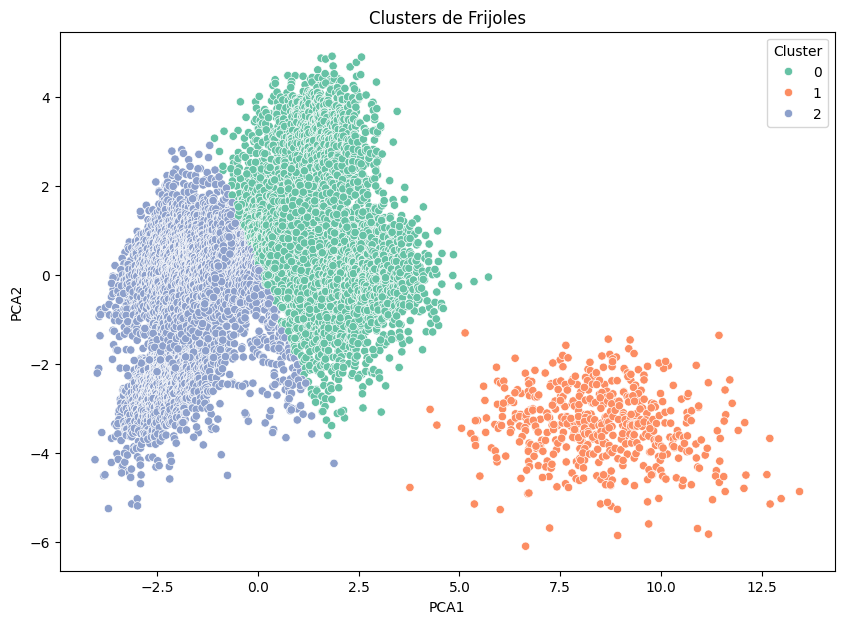

In [24]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2'
)

plt.title('Clusters de Frijoles')

plt.show()

In [ ]:
joblib.dump(
    kmeans,
    'models/kmeans_model.pkl'
)

In [ ]:
joblib.dump(
    scaler,
    'models/scaler.pkl'
)